In [1]:
%matplotlib widget

## 初期値のコード追加

In [2]:
import math
import random
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [3]:
import os
import sys

sys.path.append('/home/morita/src/3D_Estimation/src')

from plot import *
from calculate import *
from optimization_prior import *

In [4]:
# 線源
source_1 = [8.5, 3.5, 0.0,100]
source_2 = [7.0,3.0,10.0,200]
source_3 = [7.0,10,5.0,150]
source_list = []
source_list.append(source_1)
source_list.append(source_2)
source_list.append(source_3)

In [5]:
# 部屋
x = 10
y = 10
z = 10

In [6]:
g = 1
q_max = 200
q_init = 1/q_max
q1 = np.array([q_init] * (x * y)).reshape(x * y, 1)  # 地面 z=0
q2 = np.array([q_init] * (x * y)).reshape(x * y, 1)  # 天井 z=10
q3 = np.array([q_init] * (y * z)).reshape(y * z, 1)  # 側面1 x=0
q4 = np.array([q_init] * (x * z)).reshape(x * z, 1)  # 側面2 y=0
q5 = np.array([q_init] * (y * z)).reshape(y * z, 1)  # 側面3 x=10
q6 = np.array([q_init] * (x * z)).reshape(x * z, 1)  # 側面4 y=10

In [7]:
vmin = 0
vmax = 1 / q_max

In [8]:
r = 0.7
m_p = decide_measurement_points(x,y,r)
print(m_p)

[[9.5, 4.5, 0.5], [9.5, 9.5, 0.5], [7.5, 5.5, 0.5], [3.5, 9.5, 0.5], [5.5, 0.5, 0.5], [6.5, 8.5, 0.5], [2.5, 8.5, 0.5], [3.5, 3.5, 0.5], [6.5, 5.5, 0.5], [6.5, 7.5, 0.5], [2.5, 1.5, 0.5], [3.5, 6.5, 0.5], [9.5, 5.5, 0.5], [7.5, 2.5, 0.5], [2.5, 6.5, 0.5], [1.5, 3.5, 0.5], [8.5, 6.5, 0.5], [0.5, 1.5, 0.5], [7.5, 8.5, 0.5], [1.5, 5.5, 0.5], [1.5, 4.5, 0.5], [2.5, 3.5, 0.5], [4.5, 1.5, 0.5], [4.5, 7.5, 0.5], [6.5, 3.5, 0.5], [6.5, 2.5, 0.5], [2.5, 5.5, 0.5], [9.5, 2.5, 0.5], [0.5, 4.5, 0.5], [5.5, 6.5, 0.5], [7.5, 6.5, 0.5], [7.5, 0.5, 0.5], [1.5, 9.5, 0.5], [5.5, 4.5, 0.5], [5.5, 2.5, 0.5], [9.5, 8.5, 0.5], [9.5, 0.5, 0.5], [5.5, 1.5, 0.5], [3.5, 5.5, 0.5], [4.5, 9.5, 0.5], [5.5, 9.5, 0.5], [0.5, 5.5, 0.5], [4.5, 5.5, 0.5], [4.5, 8.5, 0.5], [1.5, 0.5, 0.5], [2.5, 4.5, 0.5], [6.5, 9.5, 0.5], [0.5, 6.5, 0.5], [6.5, 6.5, 0.5], [8.5, 2.5, 0.5], [4.5, 2.5, 0.5], [8.5, 9.5, 0.5], [5.5, 7.5, 0.5], [3.5, 2.5, 0.5], [4.5, 3.5, 0.5], [6.5, 0.5, 0.5], [2.5, 0.5, 0.5], [8.5, 0.5, 0.5], [9.5, 6.5, 0.

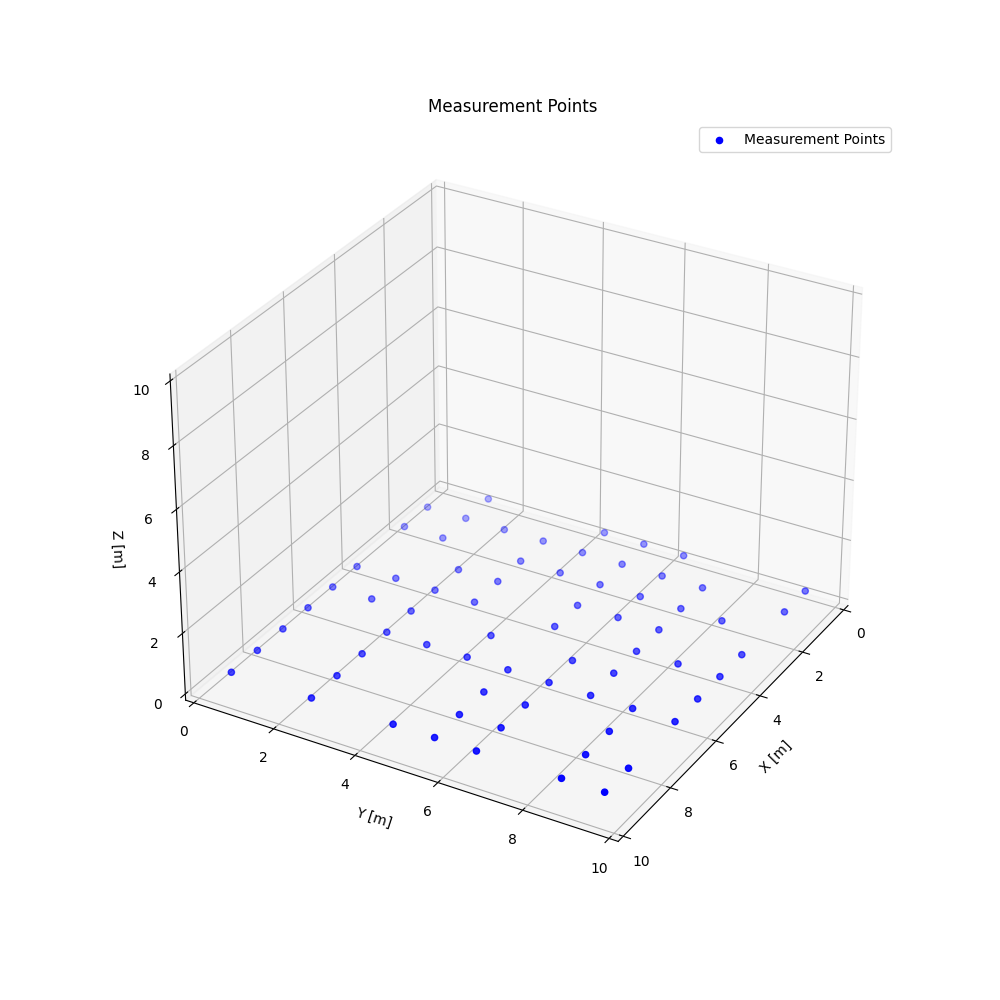

In [9]:
plot_measurement_points_3d(m_p, "Measurement Points", x, y, z)

## 以下初期値変更

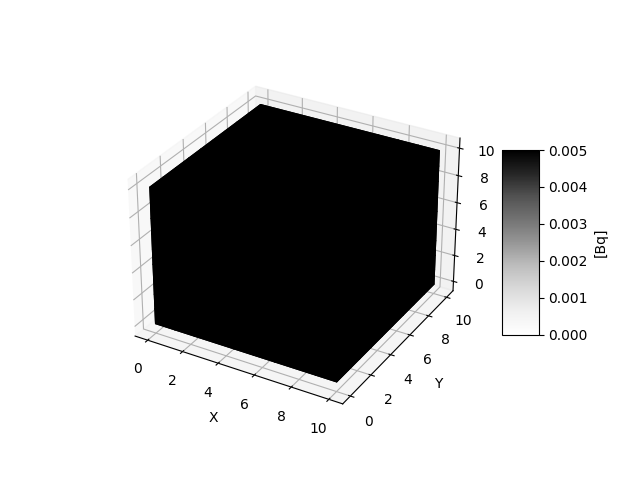

In [10]:
# 3Dヒートマップのプロット
qs = [q1, q2, q3, q4, q5, q6]
plot_3d_heatmap_cube(qs, x, y, z, sources=source_list, vmin=0, vmax=q_init)

In [11]:
# 角度の8通りのシールド向きリスト
shield_orientations = [
    {'theta': (0, np.pi / 2), 'phi': (0, np.pi / 2)},
    {'theta': (0, np.pi / 2), 'phi': (np.pi / 2, np.pi)},
    {'theta': (0, np.pi / 2), 'phi': (np.pi, 3 * np.pi / 2)},
    {'theta': (0, np.pi / 2), 'phi': (3 * np.pi / 2, 2 * np.pi)},
    {'theta': (np.pi / 2, np.pi), 'phi': (0, np.pi / 2)},
    {'theta': (np.pi / 2, np.pi), 'phi': (np.pi / 2, np.pi)},
    {'theta': (np.pi / 2, np.pi), 'phi': (np.pi, 3 * np.pi / 2)},
    {'theta': (np.pi / 2, np.pi), 'phi': (3 * np.pi / 2, 2 * np.pi)}
]

In [12]:
rad_all_measurements = measurement_shield(m_p, source_list, shield_orientations)
print(len(rad_all_measurements))
print(rad_all_measurements)

560
[49.112932706308044, 46.73876455559101, 47.29373888280504, 49.112932706308044, 49.112932706308044, 49.112932706308044, 9.191734912769828, 49.112932706308044, 9.733481835344723, 4.696695197842236, 8.438740285284023, 9.733481835344723, 9.733481835344723, 9.733481835344723, 7.322134317614225, 9.733481835344723, 24.79578410524337, 21.489427232772414, 22.938984207869503, 24.79578410524337, 24.79578410524337, 24.79578410524337, 24.79578410524337, 7.686699336584136, 3.480481739872969, 7.594498306382633, 7.594498306382633, 6.353424799847765, 7.594498306382633, 7.594498306382633, 7.594498306382633, 6.128005326211841, 5.820971205362959, 8.835145450623763, 8.835145450623763, 8.835145450623763, 3.9133539418313776, 8.835145450623763, 8.835145450623763, 8.835145450623763, 5.746149215159392, 11.668524712002974, 11.668524712002974, 10.180778210380431, 11.668524712002974, 11.668524712002974, 11.668524712002974, 8.597663343269264, 3.4107106284573874, 6.562384138473562, 6.562384138473562, 5.286040336

In [13]:
# 例: グリッド生成時に g の値を指定（省略可）
ground_grid = create_grid('z', 0, g=1)    # 地面 z=0
ceiling_grid = create_grid('z', 10, g=1)  # 天井 z=10
side1_grid = create_grid('x', 0, g=1)     # 側面1 x=0
side2_grid = create_grid('y', 0, g=1)     # 側面2 y=0
side3_grid = create_grid('x', 10, g=1)    # 側面3 x=10
side4_grid = create_grid('y', 10, g=1)    # 側面4 y=10


# 結果をリストとして保存
all_grids = {
    "ground": ground_grid,
    "ceiling": ceiling_grid,
    "side1": side1_grid,
    "side2": side2_grid,
    "side3": side3_grid,
    "side4": side4_grid
}


In [14]:
# 各面のA行列の作成
A1 = create_A(10, 10, m_p, ground_grid, shield_orientations)  # 地面 z=0
A2 = create_A(10, 10, m_p, ceiling_grid, shield_orientations) # 天井 z=10
A3 = create_A(10, 10, m_p, side1_grid, shield_orientations)   # 側面1 x=0
A4= create_A(10, 10, m_p, side2_grid, shield_orientations)   # 側面2 y=0
A5= create_A(10, 10, m_p, side3_grid, shield_orientations)   # 側面3 x=10
A6 = create_A(10, 10, m_p, side4_grid, shield_orientations)   # 側面4 y=10

In [15]:
# 全体のA行列を結合
A = np.hstack((A1, A2, A3, A4, A5, A6))

print("Final A matrix:")
print(f"A: {A.shape}")

Final A matrix:
A: (560, 600)


In [16]:
def adjust_q_based_on_measurements(m_p, rad_all_measurements, shield_orientations, q_surfaces, x, y, z, min_q_value=1e-3):
    """
    測定値に基づいて適応的に q を調整し，prior 分布を適応的に修正
    """
    num_orientations = len(shield_orientations)
    updated_q = [q.copy().astype(np.float64) for q in q_surfaces]

    for idx, detector_position in enumerate(m_p):
        measurements = rad_all_measurements[idx * num_orientations:(idx + 1) * num_orientations]
        measurement_counts = {val: measurements.count(val) for val in set(measurements)}

        # 4回以上同じ測定値が出た場合、その方向の遮蔽領域を特定
        for measurement, count in measurement_counts.items():
            if count >= 4:
                for orientation_idx, orientation in enumerate(shield_orientations):
                    if measurements[orientation_idx] == measurement:
                        for surface_idx, q_surface in enumerate(updated_q):  
                            for grid_idx in range(len(q_surface)):
                                grid_position = get_grid_position(surface_idx, grid_idx, x, y, z)

                                # **デバッグ: 遮蔽判定の確認**
                                if shield_blocks_radiation(orientation, grid_position, detector_position):
                                    print(f"Updating q: Surface {surface_idx}, Grid {grid_idx}, Before: {updated_q[surface_idx][grid_idx]}")
                                    
                                    # **減衰率を大きく**
                                    updated_q[surface_idx][grid_idx] *= 0.99
                                    updated_q[surface_idx][grid_idx] = max(updated_q[surface_idx][grid_idx], min_q_value)
                                    
                                    print(f"Updated q: Surface {surface_idx}, Grid {grid_idx}, After: {updated_q[surface_idx][grid_idx]}")

    # **正規化をスキップ**
    # total_q = sum(q_surface.sum() for q_surface in updated_q)
    # if total_q > 1e-3:
    #     updated_q = [q_surface / total_q for q_surface in updated_q]

    return updated_q




In [17]:
# qを計測結果に基づいて更新
updated_q = adjust_q_based_on_measurements(m_p, rad_all_measurements, shield_orientations, 
                                            [q1, q2, q3, q4, q5, q6], x, y, z)

Updating q: Surface 1, Grid 49, Before: [0.005]
Updated q: Surface 1, Grid 49, After: [0.00495]
Updating q: Surface 1, Grid 59, Before: [0.005]
Updated q: Surface 1, Grid 59, After: [0.00495]
Updating q: Surface 1, Grid 69, Before: [0.005]
Updated q: Surface 1, Grid 69, After: [0.00495]
Updating q: Surface 1, Grid 79, Before: [0.005]
Updated q: Surface 1, Grid 79, After: [0.00495]
Updating q: Surface 1, Grid 89, Before: [0.005]
Updated q: Surface 1, Grid 89, After: [0.00495]
Updating q: Surface 1, Grid 99, Before: [0.005]
Updated q: Surface 1, Grid 99, After: [0.00495]
Updating q: Surface 4, Grid 4, Before: [0.005]
Updated q: Surface 4, Grid 4, After: [0.00495]
Updating q: Surface 4, Grid 5, Before: [0.005]
Updated q: Surface 4, Grid 5, After: [0.00495]
Updating q: Surface 4, Grid 6, Before: [0.005]
Updated q: Surface 4, Grid 6, After: [0.00495]
Updating q: Surface 4, Grid 7, Before: [0.005]
Updated q: Surface 4, Grid 7, After: [0.00495]
Updating q: Surface 4, Grid 8, Before: [0.005]
U

KeyboardInterrupt: 

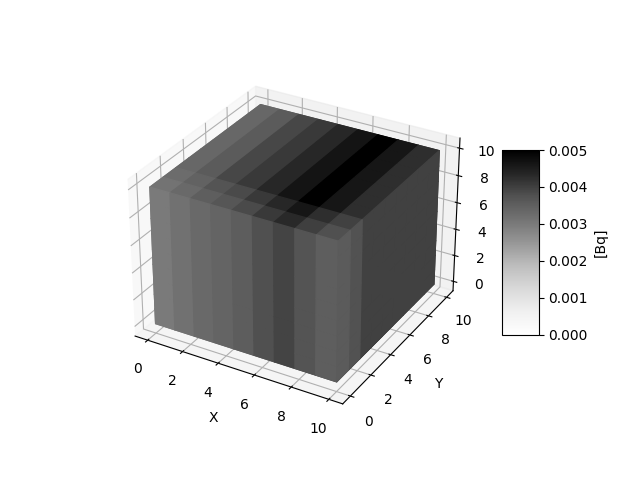

In [ ]:
plot_3d_heatmap_cube(updated_q, x, y, z, sources=source_list, vmin=0, vmax=q_init)

In [ ]:
print(updated_q)

[array([[0.00290583],
       [0.00305559],
       [0.00321306],
       [0.00331141],
       [0.00348207],
       [0.00366152],
       [0.00381171],
       [0.00404864],
       [0.00404864],
       [0.00385022],
       [0.00299478],
       [0.00314912],
       [0.00334486],
       [0.00344725],
       [0.00366152],
       [0.00385022],
       [0.00404864],
       [0.00434373],
       [0.00434373],
       [0.00408953],
       [0.00308645],
       [0.0032783 ],
       [0.00351724],
       [0.00366152],
       [0.00388911],
       [0.00413084],
       [0.00438761],
       [0.0047074 ],
       [0.0047074 ],
       [0.00438761],
       [0.00308645],
       [0.00331141],
       [0.00358865],
       [0.0037736 ],
       [0.00400815],
       [0.00430029],
       [0.00461372],
       [0.005     ],
       [0.005     ],
       [0.00466033],
       [0.00299478],
       [0.00318093],
       [0.00341277],
       [0.00355277],
       [0.00373586],
       [0.00400815],
       [0.00425729],
       [0.00

In [ ]:
prior_q_combined = np.vstack(updated_q)

In [ ]:
r_a_s = np.array(rad_all_measurements)

In [ ]:
def compute_prior_distribution_sparse(updated_q, lambda_corr=0.1, lambda_shield=10.0, grid_size=1.0, sparse_threshold=0.004):
    """
    スパース性を考慮したガウス事前分布モデル
    - updated_q: 遮蔽回転測定によって更新された q（リスト形式、6面分）
    - lambda_corr: 隣接グリッドとの相関強度（通常領域）
    - lambda_shield: 遮蔽の影響を受けたグリッドの不確実性を増加させる係数
    - grid_size: グリッドのサイズ
    - sparse_threshold: これ以上の q の値を持つグリッドを "点線源の可能性が高い" とみなす閾値

    Returns:
    - mu: 事前分布の平均ベクトル
    - Sigma_inv: 逆共分散行列（スパース性を考慮）
    """
    # 1. 平均ベクトル μ を作成
    q_flatten = np.concatenate([q.flatten() for q in updated_q])
    mu = q_flatten.copy()

    # 2. 共分散行列 Σ の作成
    sigma_q = np.std(q_flatten)
    epsilon = max(1e-4, sigma_q * 0.01)
    grid_count = len(q_flatten)

    # 初期化
    Sigma = np.eye(grid_count) * epsilon  

    # 3. インデックスマップの作成（6面のグリッドを1Dに展開）
    index_map = {}
    idx = 0
    for surface_idx, q_surface in enumerate(updated_q):
        for grid_idx in range(len(q_surface)):
            index_map[(surface_idx, grid_idx)] = idx
            idx += 1

    # 4. スパース性を考慮した共分散行列の調整
    for (s1, g1), idx1 in index_map.items():
        q_val1 = updated_q[s1][g1]  # 現在の q の値
        for (s2, g2), idx2 in index_map.items():
            q_val2 = updated_q[s2][g2]

            if s1 == s2 and abs(g1 - g2) == 1:
                # 隣接グリッドの場合の共分散
                if q_val1 > sparse_threshold or q_val2 > sparse_threshold:
                    # 点線源の可能性が高い場合は相関を減らす
                    Sigma[idx1, idx2] += lambda_corr * 0.1  # 相関を小さく
                else:
                    # 通常のグリッド
                    Sigma[idx1, idx2] += lambda_corr

            if idx1 == idx2:
                # 自己相関の調整
                if q_val1 > sparse_threshold:
                    Sigma[idx1, idx2] += lambda_shield * 10  # 高い自己相関（スパース性を反映）
                else:
                    Sigma[idx1, idx2] += lambda_shield

    # 数値安定性のための正則化
    Sigma += np.eye(grid_count) * epsilon

    # 逆共分散行列の計算（擬似逆行列）
    Sigma_inv = np.linalg.pinv(Sigma)

    return mu, Sigma_inv

In [ ]:
mu, Sigma_inv = compute_prior_distribution_sparse(updated_q)

print("Shape of mu:", mu.shape)
print("Shape of q:", prior_q_combined.shape)
print("Shape of Sigma_inv:", Sigma_inv.shape)


mu = mu.reshape(prior_q_combined.shape)  # (600,) -> (600,1) に変換

print("Shape of mu:", mu.shape)
print("Shape of q:", prior_q_combined.shape)
print("Shape of Sigma_inv:", Sigma_inv.shape)

print("Sigma_inv の対角成分の最大値:", np.max(np.diag(Sigma_inv)))
print("Sigma_inv の対角成分の最小値:", np.min(np.diag(Sigma_inv)))

Shape of mu: (600,)
Shape of q: (600, 1)
Shape of Sigma_inv: (600, 600)
Shape of mu: (600, 1)
Shape of q: (600, 1)
Shape of Sigma_inv: (600, 600)
Sigma_inv の対角成分の最大値: 1.1838697947676318
Sigma_inv の対角成分の最小値: -0.5572378903227801


In [ ]:
init_score = score_func_prior(A, r_a_s, prior_q_combined, mu, Sigma_inv, lam=0.01, alpha=0)
print(f'Initial score: {init_score}')

[[-0.]]
Initial score: -11429587.612552932


In [ ]:
prior_q_optimized = Adam_prior(A, r_a_s, prior_q_combined, mu, Sigma_inv, lam=0.01, alpha=0, learning_rate=10, beta1=0.9, beta2=0.999, epsilon=1e-8, max_iter=100000)

In [ ]:
final_score = score_func(A, r_a_s, q_optimized_initial, mu, Sigma_inv)
print(f'Final score: {final_score}')

[[-0.05495147]]
Final score: 13611554.816395918


In [ ]:
q_shapes = [
    (x * y, 1),  # 地面 z=0 に対応
    (x * y, 1),  # 天井 z=10 に対応
    (y * z, 1),  # 側面1 x=0 に対応
    (x * z, 1),  # 側面2 y=0 に対応
    (y * z, 1),  # 側面3 x=10 に対応
    (x * z, 1)   # 側面4 y=10 に対応
]
prior_restored_q= restore_q(prior_q_optimized, q_shapes)

In [ ]:
# 各qの最大値と最小値を求める
all_q_values_initial = np.concatenate([q.flatten() for q in restored_qs_initial])
vmin_ini, vmax_ini = all_q_values_initial.min(), all_q_values_initial.max()

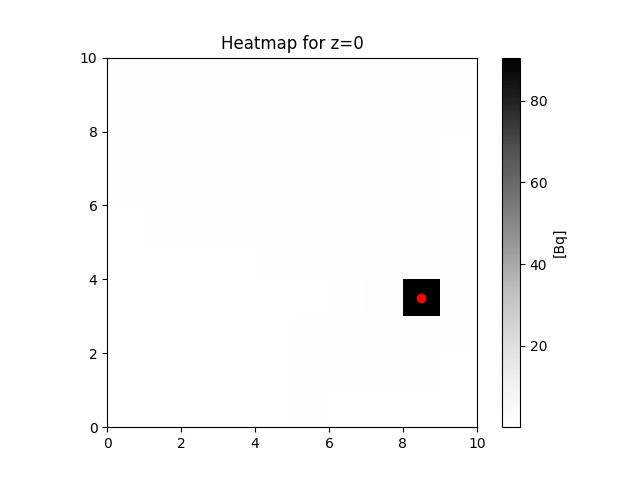

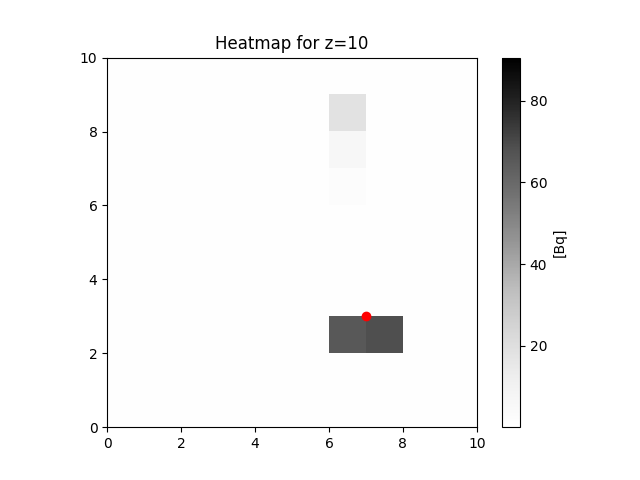

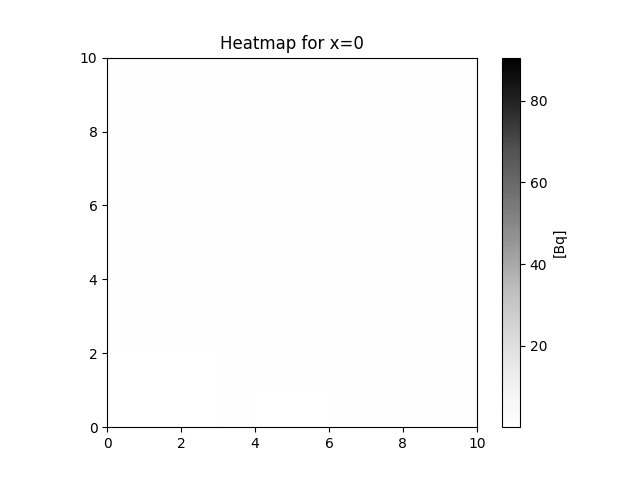

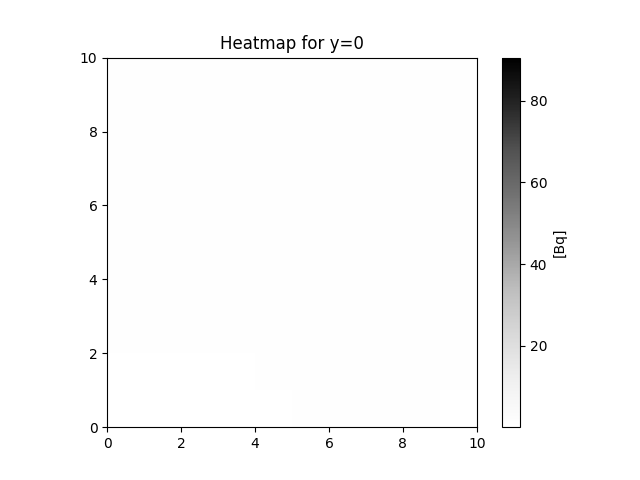

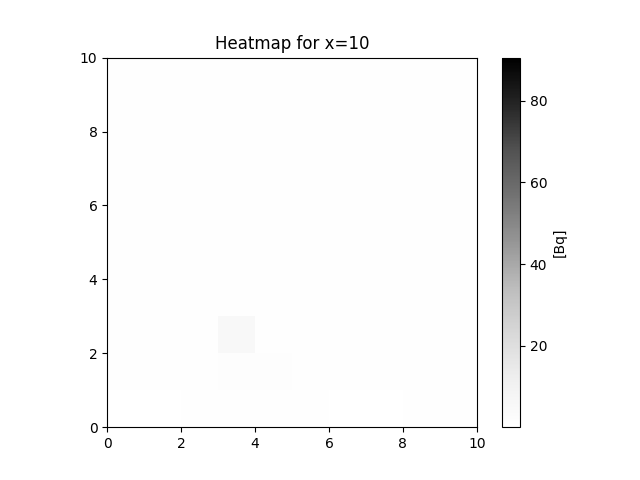

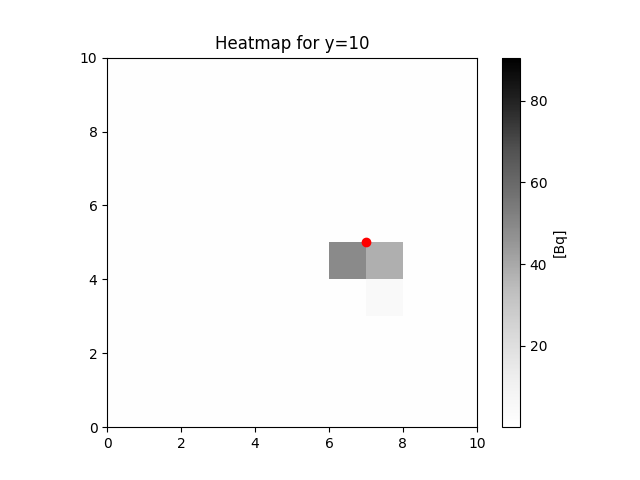

In [ ]:
source_list = []
source_list.append(source_1)
source_list.append(source_2)
source_list.append(source_3)

# 地面 z=0
plot_heatmap(restored_qs_initial[0].reshape((x, y)), (x, y), [0, x, 0, y], 'Heatmap for z=0', sources=[(source[0], source[1]) for source in source_list if source[2] == 0], vmin=vmin_ini, vmax=vmax_ini)

# 天井 z=10
plot_heatmap(restored_qs_initial[1].reshape((x, y)), (x, y), [0, x, 0, y], 'Heatmap for z=10', sources=[(source[0], source[1]) for source in source_list if source[2] == 10], vmin=vmin_ini, vmax=vmax_ini)

# 側面1 x=0
plot_heatmap(restored_qs_initial[2].reshape((y, z)), (y, z), [0, y, 0, z], 'Heatmap for x=0', sources=[(source[1], source[2]) for source in source_list if source[0] == 0], vmin=vmin_ini, vmax=vmax_ini)

# 側面2 y=0
plot_heatmap(restored_qs_initial[3].reshape((x, z)), (x, z), [0, x, 0, z], 'Heatmap for y=0', sources=[(source[0], source[2]) for source in source_list if source[1] == 0], vmin=vmin_ini, vmax=vmax_ini)

# 側面3 x=10
plot_heatmap(restored_qs_initial[4].reshape((y, z)), (y, z), [0, y, 0, z], 'Heatmap for x=10', sources=[(source[1], source[2]) for source in source_list if source[0] == 10], vmin=vmin_ini, vmax=vmax_ini)

# 側面4 y=10
plot_heatmap(restored_qs_initial[5].reshape((x, z)), (x, z), [0, x, 0, z], 'Heatmap for y=10', sources=[(source[0], source[2]) for source in source_list if source[1] == 10], vmin=vmin_ini, vmax=vmax_ini)

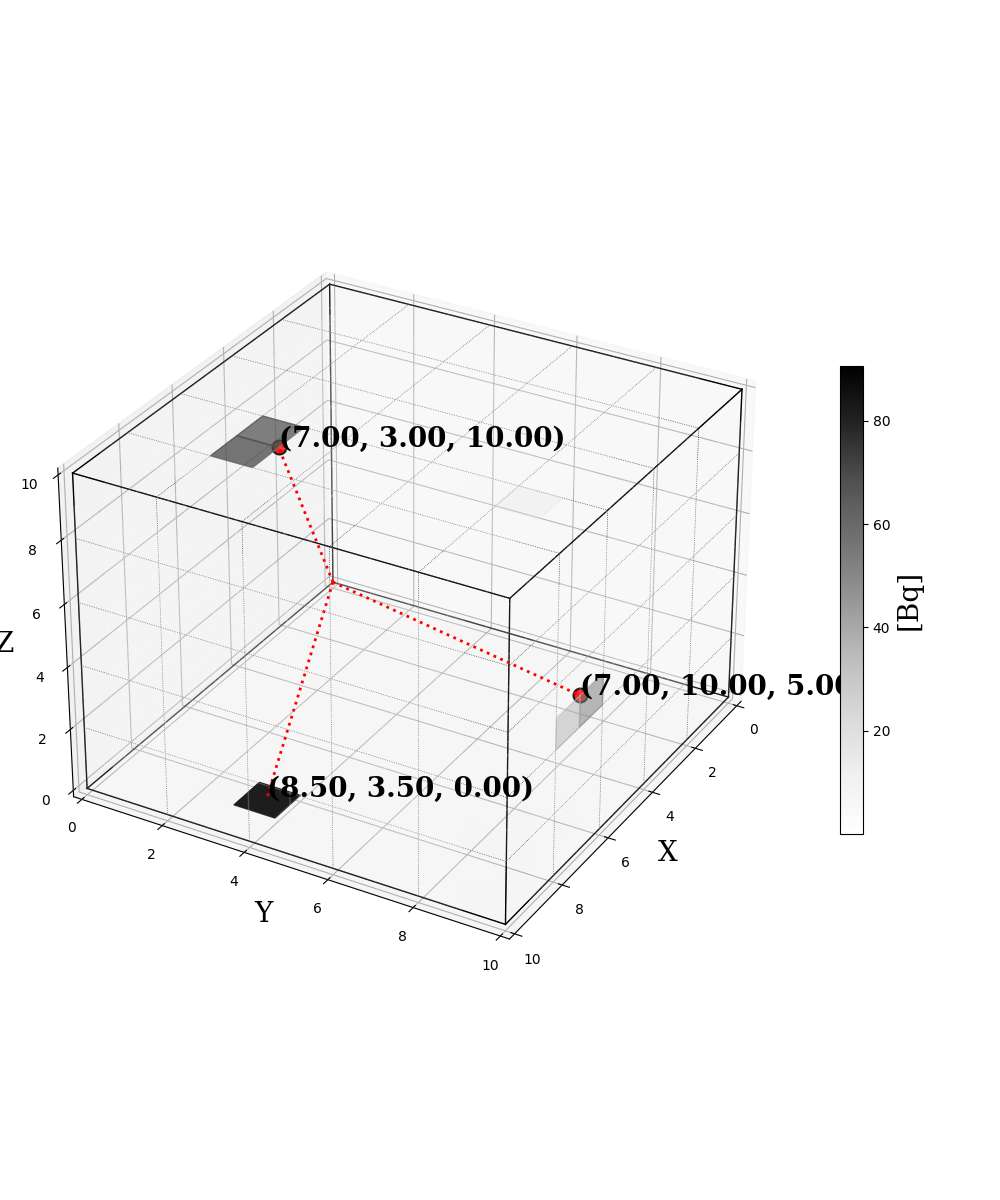

In [ ]:
# 各面のデータと最小・最大の放射線量を設定
source_list = [radiation_source(*src) for src in [source_1, source_2, source_3]]

qs = restored_qs_initial

plot_3d_heatmap(qs, x, y, z, sources=source_list, vmin=vmin_ini, vmax=vmax_ini)